# Task-02: Titanic Dataset – Data Cleaning and Exploratory Data Analysis (EDA)

**Objective:** Perform data cleaning and exploratory data analysis (EDA) on the Titanic dataset. Explore relationships between variables and identify patterns and trends.


## 1. Import Required Libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')


## 2. Upload and Load the Dataset


In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('titanic_task02_dataset.csv')
df.head()


Saving titanic_task02_dataset.csv to titanic_task02_dataset.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,Passenger_1,female,NaN,0,0,TKT-10000,33.18,NaN,Q
1,2,0,3,Passenger_2,male,NaN,0,0,TKT-10001,8.78,NaN,S
2,3,0,3,Passenger_3,male,28.5,0,0,TKT-10002,2.46,C2,S
3,4,0,3,Passenger_4,male,15.5,0,2,TKT-10003,12.12,NaN,S
4,5,0,1,Passenger_5,male,22.2,0,0,TKT-10004,64.09,NaN,C


## 3. Basic Information About the Dataset


In [3]:
print('Dataset Shape:', df.shape)
df.info()
display(df.describe(include='all'))


Dataset Shape: (300, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  300 non-null    int64  
 1   Survived     300 non-null    int64  
 2   Pclass       300 non-null    int64  
 3   Name         300 non-null    object 
 4   Sex          300 non-null    object 
 5   Age          245 non-null    float64
 6   SibSp        300 non-null    int64  
 7   Parch        300 non-null    int64  
 8   Ticket       300 non-null    object 
 9   Fare         300 non-null    float64
 10  Cabin        80 non-null     object 
 11  Embarked     291 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 28.3+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,300.000000,300.000000,300.000000,300,300,245.000000,300.000000,300.000000,300,300.000000,80,291
unique,NaN,NaN,NaN,300,2,NaN,NaN,NaN,300,NaN,68,3
top,NaN,NaN,NaN,Passenger_300,male,NaN,NaN,NaN,TKT-10299,NaN,C8,S
freq,NaN,NaN,NaN,1,199,NaN,NaN,NaN,1,NaN,2,205
mean,150.500000,0.360000,2.336667,NaN,NaN,28.592245,0.383333,0.316667,NaN,34.818433,NaN,NaN
std,86.746758,0.480802,0.823965,NaN,NaN,14.148025,0.686508,0.646360,NaN,41.394075,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,1.000000,0.000000,0.000000,NaN,1.350000,NaN,NaN
25%,75.750000,0.000000,2.000000,NaN,NaN,19.100000,0.000000,0.000000,NaN,8.947500,NaN,NaN
50%,150.500000,0.000000,3.000000,NaN,NaN,27.800000,0.000000,0.000000,NaN,17.015000,NaN,NaN
75%,225.250000,1.000000,3.000000,NaN,NaN,38.300000,1.000000,0.000000,NaN,42.567500,NaN,NaN


## 4. Check Missing Values


Cabin          220
Age             55
Embarked         9
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64


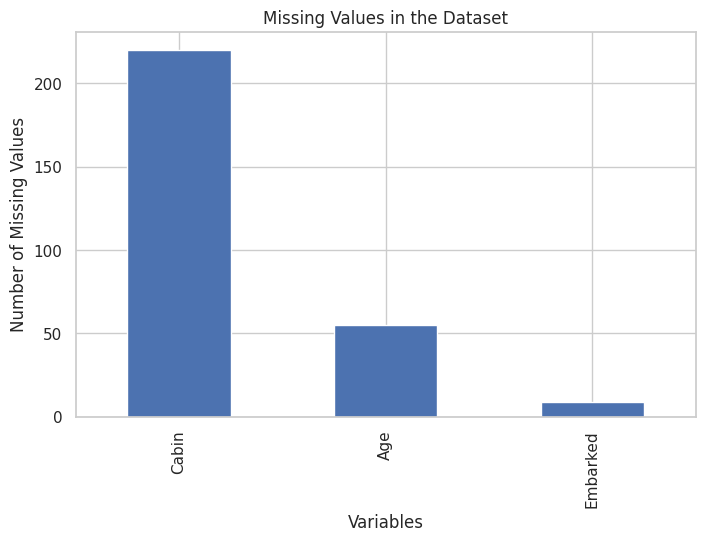

In [4]:
missing_values = df.isnull().sum().sort_values(ascending=False)
print(missing_values)
plt.figure(figsize=(8,5))
missing_values[missing_values > 0].plot(kind='bar')
plt.title('Missing Values in the Dataset')
plt.xlabel('Variables')
plt.ylabel('Number of Missing Values')
plt.show()


## 5. Data Cleaning

Age missing values are replaced with the median, Embarked missing values with the mode, and Cabin is dropped because of many missing values.


In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns=['Cabin'])
print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## 6. Age Distribution


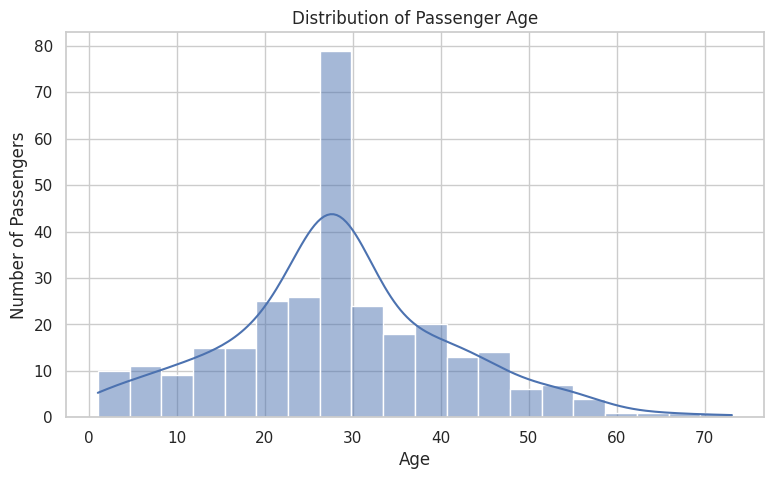

In [6]:
plt.figure(figsize=(9,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Passenger Age')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()


## 7. Survival Distribution


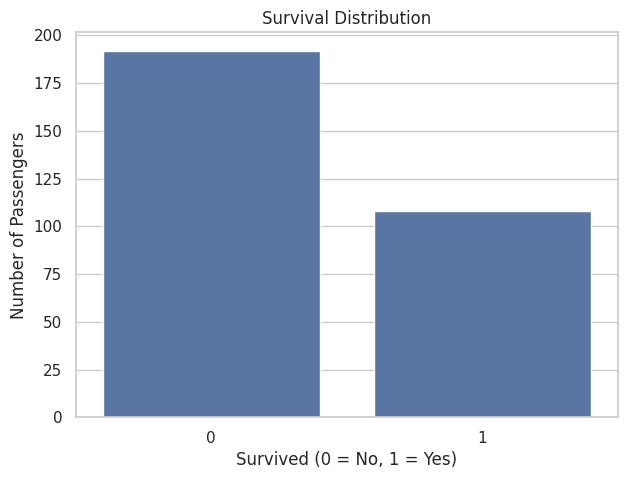

Survived
0    192
1    108
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Survived')
plt.title('Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()
print(df['Survived'].value_counts())


## 8. Relationship Between Gender and Survival


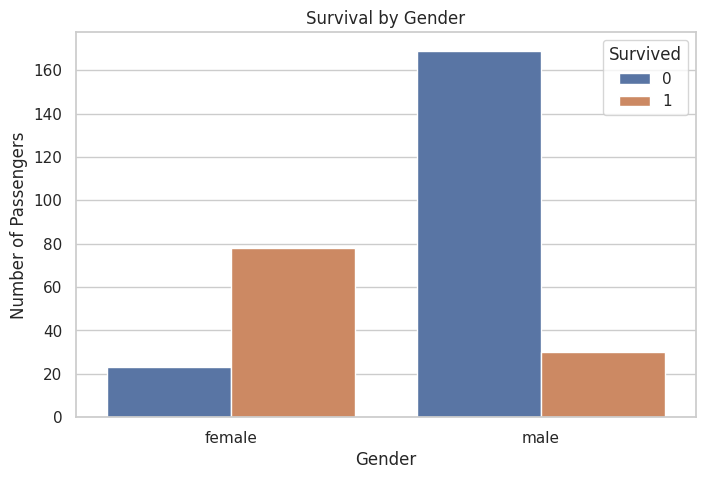

Survived          0          1
Sex                           
female    22.772277  77.227723
male      84.924623  15.075377


In [8]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')
plt.show()
print(pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100)


## 9. Relationship Between Passenger Class and Survival


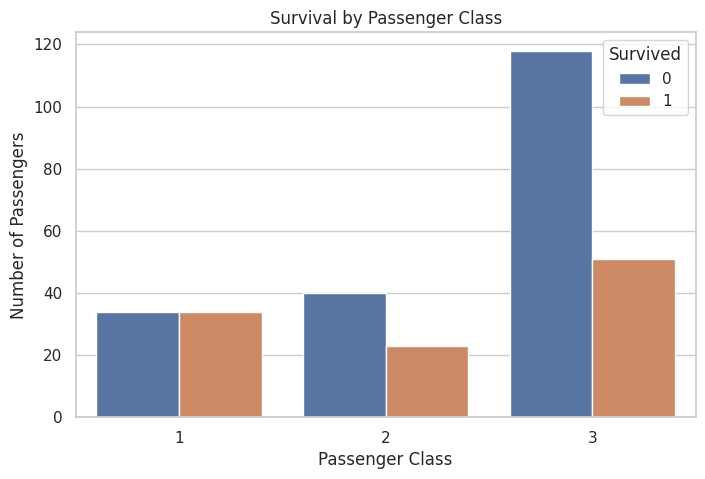

Survived          0          1
Pclass                        
1         50.000000  50.000000
2         63.492063  36.507937
3         69.822485  30.177515


In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.show()
print(pd.crosstab(df['Pclass'], df['Survived'], normalize='index') * 100)


## 10. Fare Distribution by Passenger Class


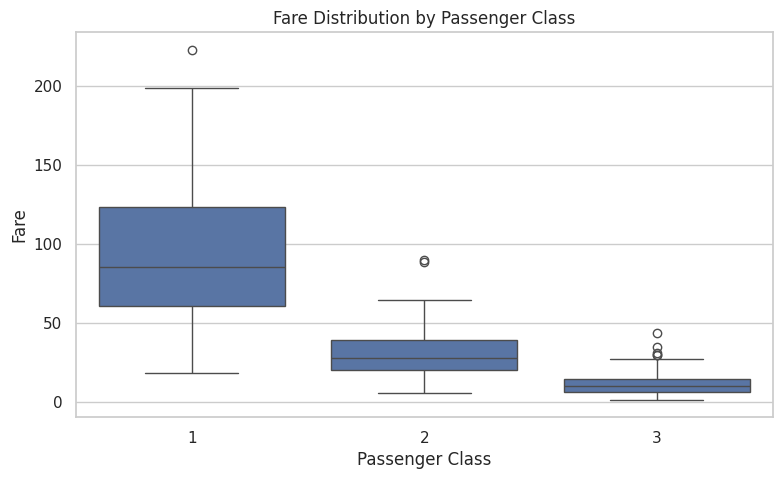

In [10]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Pclass', y='Fare')
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()


## 11. Correlation Analysis


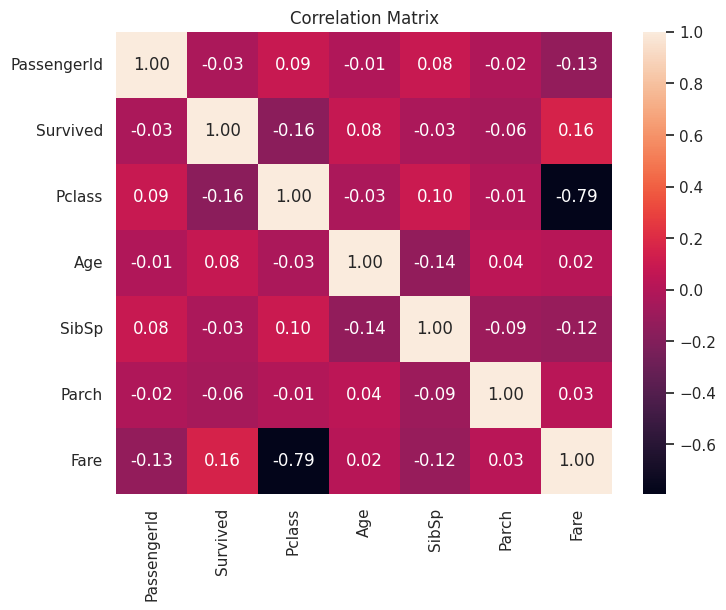

In [11]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


## 12. Key Findings and Conclusion

1. Missing values were identified in Age, Cabin, and Embarked.
2. Age was filled using the median and Embarked using the mode.
3. Cabin was removed because it contained many missing values.
4. Gender and passenger class show clear relationships with survival.
5. Age and Fare distributions provide useful insights into passenger characteristics.

Overall, EDA helps identify important patterns and trends before further statistical analysis or predictive modeling.
